# Visualização dos Mapas de Características (reais)

Esta visualização mostra o que **o seu modelo treinado** (`melhor_modelo.keras`) realmente extrai em cada camada, a partir de um raio-X real.

Como funciona de verdade:
- A **Camada 1** detecta padrões simples (bordas, texturas).
- Cada camada seguinte recebe **os mapas da camada anterior** como entrada e os combina em padrões mais complexos.
- As camadas profundas ficam **abstratas** (não parecem mais um pulmão) — isso é esperado e é justamente a "hierarquia de características".

Para ficar legível (e não escuro como numa seleção aleatória), em cada camada mostramos os **filtros que mais se ativam** para a imagem, com o contraste ajustado.

## 1. Carregar o modelo e montar o extrator de ativações

Reconstruímos o fluxo da rede e capturamos a saída das 5 camadas de convolução. Assim conseguimos ver o mapa de características produzido por cada uma.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
import pathlib
import tensorflow as tf
from tensorflow import keras

modelo = keras.models.load_model("melhor_modelo.keras")

# camadas de convolução (na ordem da rede)
conv_layers = [l for l in modelo.layers if isinstance(l, keras.layers.Conv2D)]
print("Convoluções encontradas:", [l.name for l in conv_layers])

# extrator: devolve a saída de cada convolução
entrada = keras.Input(shape=(300, 300, 3))
x = entrada
saidas = []
for layer in modelo.layers:
    x = layer(x)
    if isinstance(layer, keras.layers.Conv2D):
        saidas.append(x)
extrator = keras.Model(entrada, saidas)
print("Extrator pronto. Tamanhos das saídas:")
for i, s in enumerate(saidas):
    print(f"  Camada {i+1}: {s.shape}")

I0000 00:00:1791659364.941505   22950 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791659364.992614   22950 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791659366.813329   22950 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1791659368.056083   22950 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Convoluções encontradas: ['conv2d', 'conv2d_1', 'conv2d_2', 'conv2d_3', 'conv2d_4']
Extrator pronto. Tamanhos das saídas:
  Camada 1: (None, 300, 300, 16)
  Camada 2: (None, 150, 150, 32)
  Camada 3: (None, 75, 75, 64)
  Camada 4: (None, 37, 37, 128)
  Camada 5: (None, 18, 18, 256)


## 2. Escolher a imagem

Escolha qual raio-X visualizar. A imagem é carregada em 0–255 (a normalização acontece dentro do modelo, na camada Rescaling).

In [2]:
# Troque o caminho para a imagem que quiser (uma das 4 classes)
CAMINHO_IMAGEM = "dataset_unificado/COVID-19/COVID-1.png"   # <-- ajuste o nome do arquivo

def carregar(caminho):
    img = tf.io.read_file(caminho)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (300, 300))
    return img   # 0-255

img = carregar(CAMINHO_IMAGEM)
img_cinza = tf.image.rgb_to_grayscale(img).numpy().squeeze() / 255.0

# roda a imagem pela rede e pega os mapas de cada camada
mapas_por_camada = extrator.predict(tf.expand_dims(img, 0), verbose=0)
print("OK — mapas gerados para", len(mapas_por_camada), "camadas.")

OK — mapas gerados para 5 camadas.


## 3. Funções de renderização

`normaliza` realça o contraste de um mapa (percentil + gamma). `figura_camada` monta, para uma camada, os **N filtros mais ativos** no estilo figura científica.

In [3]:
COR = "gray"   # experimente "inferno" ou "magma" para um visual mais vibrante
N_FILTROS = 5  # quantos filtros (mais ativos) mostrar por camada

def normaliza(m):
    m = np.maximum(m, 0)
    hi = np.percentile(m, 99.0)
    if hi > 0:
        m = np.clip(m / hi, 0, 1)
    return m ** 0.7

def figura_camada(L, salvar=True):
    maps = mapas_por_camada[L][0]          # (H, W, C)
    energia = maps.mean(axis=(0, 1))       # ativação média por filtro
    idx = np.argsort(energia)[::-1][:N_FILTROS]   # filtros mais ativos
    n_canais = maps.shape[-1]
    tam = maps.shape[0]

    fig = plt.figure(figsize=(2.3*(N_FILTROS+1), 2.9), dpi=120)
    fig.patch.set_facecolor("white")
    gs = gridspec.GridSpec(1, N_FILTROS + 2, width_ratios=[1.2, 0.15] + [1]*N_FILTROS, wspace=0.08)

    fig.text(0.5, 1.12, f"Camada {L+1} — {n_canais} filtros ({N_FILTROS} mais ativos)",
             ha="center", fontsize=14, fontweight="bold", color="#1a2b4a")
    fig.text(0.5, 1.0, f"mapa {tam}x{tam}  ·  saida real do seu modelo",
             ha="center", fontsize=9, color="#6b7a8d")

    # imagem de entrada (referencia)
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.imshow(img_cinza, cmap="gray"); ax0.set_xticks([]); ax0.set_yticks([])
    ax0.set_title("Raio-X", fontsize=10, color="#1a2b4a", pad=5)
    for s in ax0.spines.values(): s.set_color("#1a2b4a"); s.set_linewidth(1.3)

    axa = fig.add_subplot(gs[0, 1]); axa.axis("off")
    axa.annotate("", xy=(0.9, 0.5), xytext=(0.0, 0.5),
                 arrowprops=dict(arrowstyle="-|>", color="#1a2b4a", lw=1.8))

    for col, f in enumerate(idx):
        ax = fig.add_subplot(gs[0, 2 + col])
        ax.imshow(normaliza(maps[:, :, f]), cmap=COR)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f"Filtro #{f}", fontsize=9, color="#1a2b4a", pad=5)
        for s in ax.spines.values(): s.set_color("#c3ccd8"); s.set_linewidth(1)

    if salvar:
        fig.savefig(f"camada_real_{L+1}.png", bbox_inches="tight", facecolor="white")
    plt.show()

## 4. Gerar as 5 camadas

Uma figura por camada. Observe a progressão: a Camada 1 realça bordas/estruturas reconhecíveis; as camadas seguintes vão ficando abstratas — é a rede construindo conceitos cada vez mais complexos a partir dos mapas anteriores.

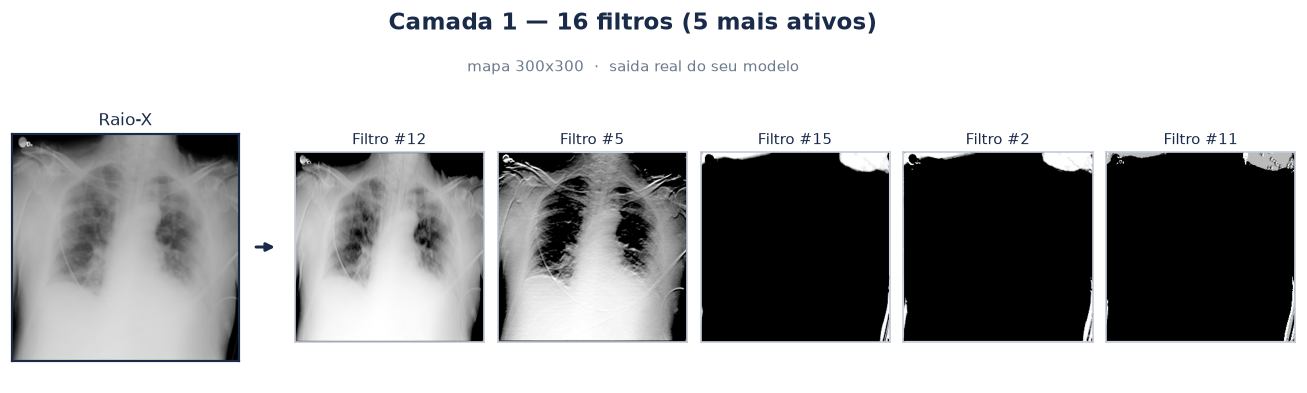

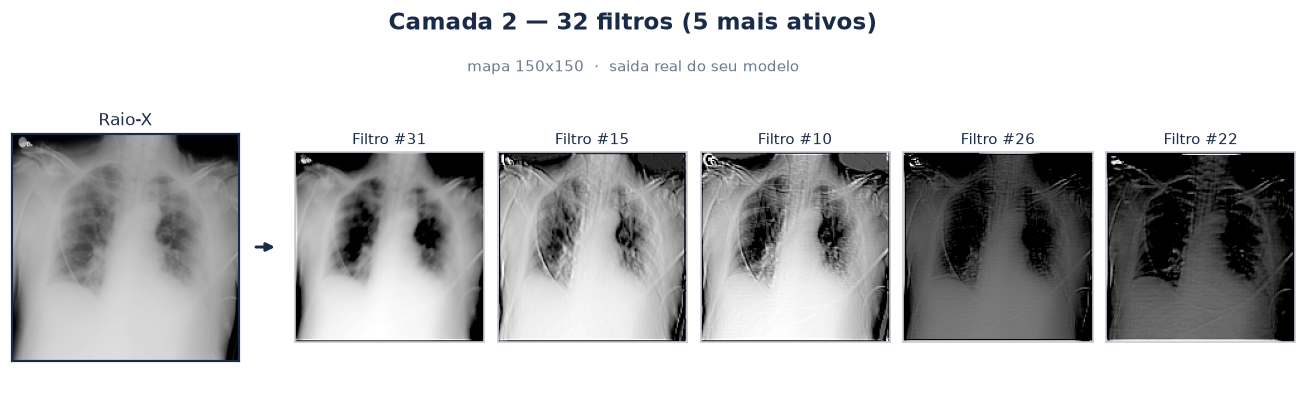

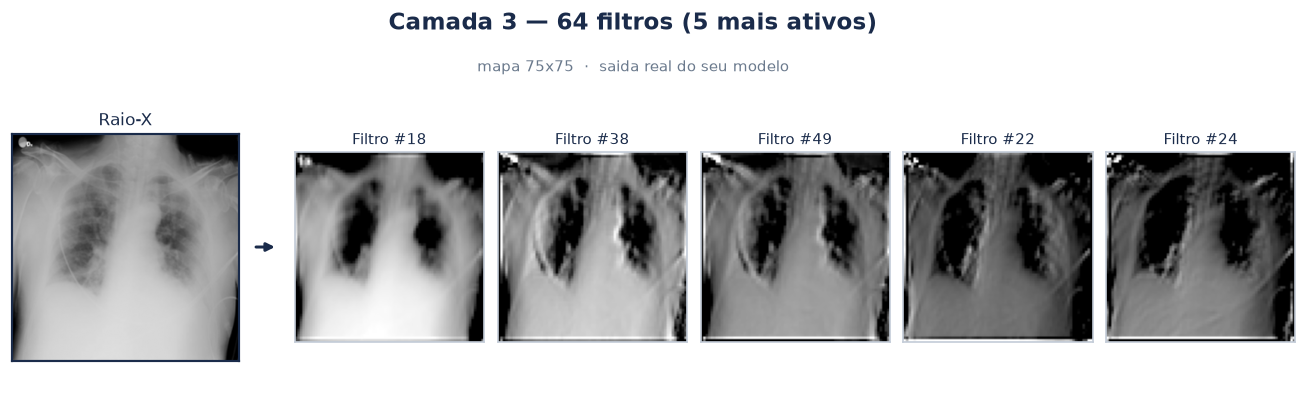

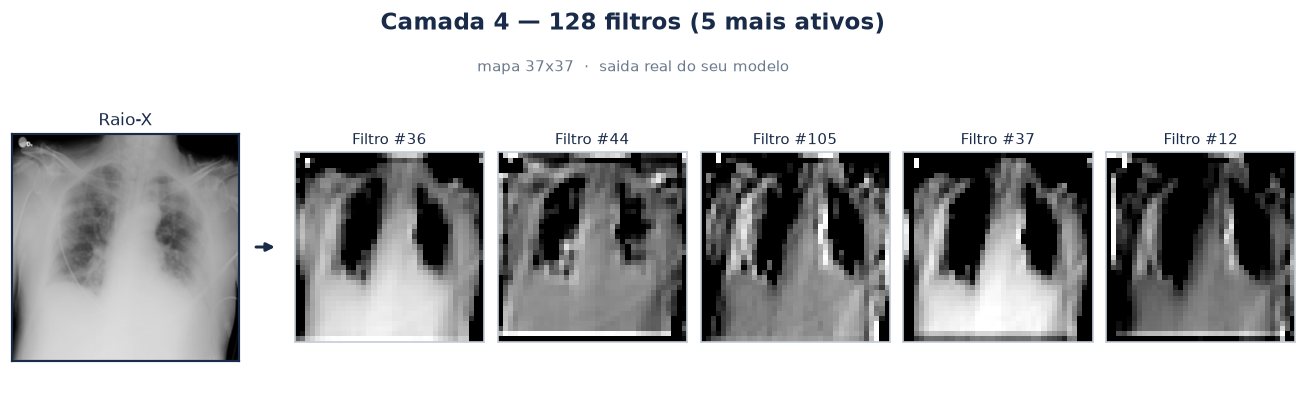

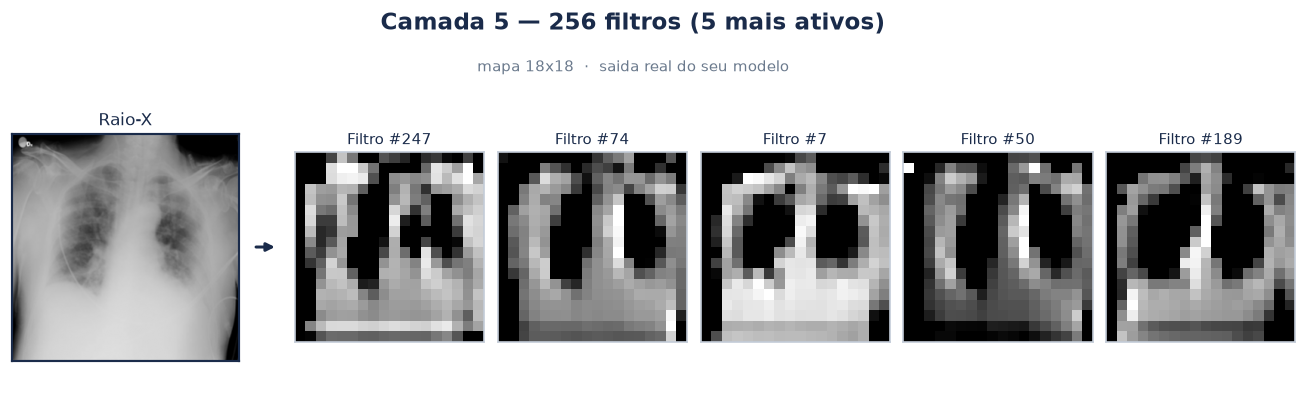

In [4]:
for L in range(5):
    figura_camada(L)

## 5. Visão geral — a progressão numa tira só

Mostra o raio-X e, em seguida, um filtro representativo de cada camada, lado a lado: dá pra ver a imagem virando padrões cada vez mais abstratos conforme avança na rede.

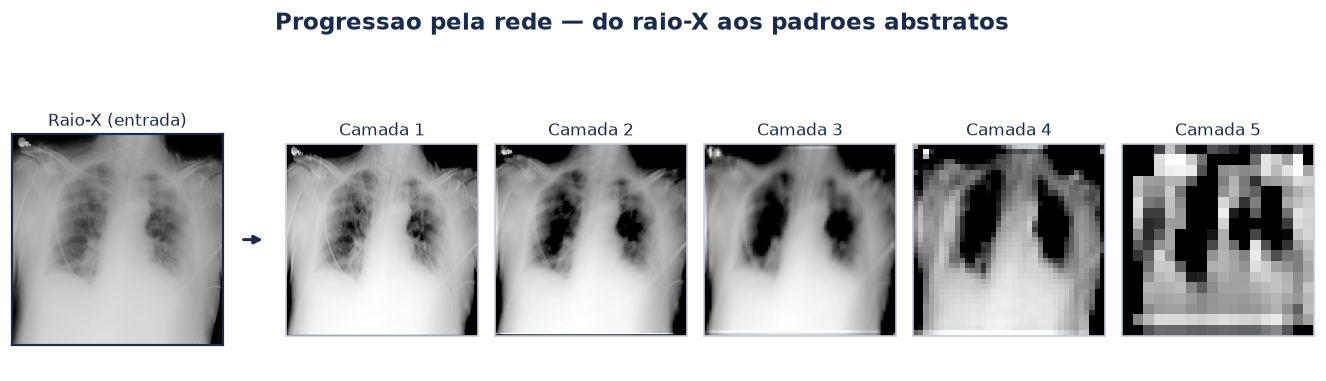

In [5]:
fig = plt.figure(figsize=(14, 2.8), dpi=120)
fig.patch.set_facecolor("white")
gs = gridspec.GridSpec(1, 7, width_ratios=[1.1, 0.15, 1, 1, 1, 1, 1], wspace=0.1)
fig.text(0.5, 1.12, "Progressao pela rede — do raio-X aos padroes abstratos",
         ha="center", fontsize=14, fontweight="bold", color="#1a2b4a")

ax0 = fig.add_subplot(gs[0, 0])
ax0.imshow(img_cinza, cmap="gray"); ax0.set_xticks([]); ax0.set_yticks([])
ax0.set_title("Raio-X (entrada)", fontsize=10, color="#1a2b4a", pad=5)
for s in ax0.spines.values(): s.set_color("#1a2b4a"); s.set_linewidth(1.3)

axa = fig.add_subplot(gs[0, 1]); axa.axis("off")
axa.annotate("", xy=(0.9, 0.5), xytext=(0.0, 0.5),
             arrowprops=dict(arrowstyle="-|>", color="#1a2b4a", lw=1.8))

for L in range(5):
    maps = mapas_por_camada[L][0]
    f = int(np.argmax(maps.mean(axis=(0, 1))))   # filtro mais ativo
    ax = fig.add_subplot(gs[0, 2 + L])
    ax.imshow(normaliza(maps[:, :, f]), cmap=COR); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"Camada {L+1}", fontsize=10, color="#1a2b4a", pad=5)
    for s in ax.spines.values(): s.set_color("#c3ccd8"); s.set_linewidth(1)

fig.savefig("progressao_camadas.png", bbox_inches="tight", facecolor="white")
plt.show()